# Version 21 : CoxNet (Cox Elastic Net)

**Objectif** : Modèle Cox avec régularisation Elastic Net (L1 + L2)

**Avantages** :
- ⚡ Très rapide à entraîner
- 🎯 Feature selection automatique (L1)
- 📊 Interprétable
- 🔧 Moins de risque d'overfitting (régularisation)

**Stratégie** :
- Réutiliser le feature engineering de V20
- Cross-validation pour sélectionner alpha optimal
- Comparer avec RSF et Neural Network

## 1. Setup & Imports

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Survival analysis
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Set random seed
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 2. Data Loading

In [2]:
# Load data
import os
DATA_PATH = "C:/Users/guill/Desktop/Data Challenge QRT/Data-Challenge-Prediction-de-Survie"

clinical_train = pd.read_csv(os.path.join(DATA_PATH, "X_train", "clinical_train.csv"))
target_train = pd.read_csv(os.path.join(DATA_PATH, "target_train.csv"))
clinical_test = pd.read_csv(os.path.join(DATA_PATH, "X_test", "clinical_test.csv"))
molecular_train = pd.read_csv(os.path.join(DATA_PATH, "X_train", "molecular_train.csv"))
molecular_test = pd.read_csv(os.path.join(DATA_PATH, "X_test", "molecular_test.csv"))

print(f"✓ Data loaded: {clinical_train.shape[0]} train patients")
print(f"  Test patients: {clinical_test.shape[0]}")

✓ Data loaded: 3323 train patients
  Test patients: 1193


## 3. Feature Engineering (same as V20)

In [3]:
def create_cytogenetic_features(clinical_df):
    """Create cytogenetic features from CYTOGENETICS column"""
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    
    # Anomaly types
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    
    # Complexity
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    
    # Prognostic markers
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    """Create molecular features"""
    mol_features = pd.DataFrame({'ID': patient_ids})
    
    # Mutation counts
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    
    # VAF stats
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    
    # Effect types
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    
    # Top genes
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


## 4. Build Features

In [4]:
# Clean target
target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

# Clinical features - TRAIN
clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_clinical_train = clinical_train_clean[numeric_features].copy()
center_encoded_train = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical_train = pd.concat([X_clinical_train, center_encoded_train], axis=1)

# Clinical features - TEST
X_clinical_test = clinical_test.set_index('ID')[numeric_features].copy()
center_encoded_test = pd.get_dummies(clinical_test.set_index('ID')['CENTER'], prefix='CENTER', drop_first=True)
X_clinical_test = pd.concat([X_clinical_test, center_encoded_test], axis=1)

# Ensure same columns
for col in X_clinical_train.columns:
    if col not in X_clinical_test.columns:
        X_clinical_test[col] = 0
X_clinical_test = X_clinical_test[X_clinical_train.columns]

# Cytogenetic + Molecular features
cyto_features_train = create_cytogenetic_features(clinical_train)
cyto_features_test = create_cytogenetic_features(clinical_test)

train_patient_ids = clinical_train_clean.index.unique()
test_patient_ids = clinical_test['ID'].unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids, top_n_genes=20)
mol_features_test = create_molecular_features(molecular_test, test_patient_ids, top_n_genes=20)

# Ensure same columns in molecular
for col in mol_features_train.columns:
    if col not in mol_features_test.columns:
        mol_features_test[col] = 0
mol_features_test = mol_features_test[mol_features_train.columns]

# Combine all features
mol_features_train_aligned = mol_features_train.reindex(X_clinical_train.index, fill_value=0)
cyto_features_train_aligned = cyto_features_train.reindex(X_clinical_train.index, fill_value=0)
X_combined_train = pd.concat([X_clinical_train, mol_features_train_aligned, cyto_features_train_aligned], axis=1)

mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)
X_combined_test = pd.concat([X_clinical_test, mol_features_test_aligned, cyto_features_test_aligned], axis=1)

print(f"✓ Combined features shape (train): {X_combined_train.shape}")
print(f"✓ Combined features shape (test): {X_combined_test.shape}")

✓ Combined features shape (train): (3173, 105)
✓ Combined features shape (test): (1193, 105)


## 5. Preprocessing

In [5]:
# Imputation
imputer = SimpleImputer(strategy='median')
X_imputed_train = pd.DataFrame(
    imputer.fit_transform(X_combined_train),
    index=X_combined_train.index,
    columns=X_combined_train.columns
)

X_imputed_test = pd.DataFrame(
    imputer.transform(X_combined_test),
    index=X_combined_test.index,
    columns=X_combined_test.columns
)

# Standardization (important for penalized models)
scaler = StandardScaler()
X_scaled_train = pd.DataFrame(
    scaler.fit_transform(X_imputed_train),
    index=X_imputed_train.index,
    columns=X_imputed_train.columns
)

X_scaled_test = pd.DataFrame(
    scaler.transform(X_imputed_test),
    index=X_imputed_test.index,
    columns=X_imputed_test.columns
)

# Create survival target
y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_train, y_surv, test_size=0.2, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"✓ Preprocessed data:")
print(f"  Train: {X_train.shape[0]} patients, {X_train.shape[1]} features")
print(f"  Val: {X_val.shape[0]} patients")
print(f"  Test: {X_scaled_test.shape[0]} patients")

✓ Preprocessed data:
  Train: 2538 patients, 105 features
  Val: 635 patients
  Test: 1193 patients


## 6. CoxNet with Cross-Validation

In [6]:
print("="*60)
print("COXNET MODEL TRAINING")
print("="*60)
print("\nTesting multiple alpha values...\n")

# Test different alpha values (regularization strength)
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
results = []

for alpha in alphas:
    # CoxNet with Elastic Net (l1_ratio=0.5 means 50% L1 + 50% L2)
    coxnet = CoxnetSurvivalAnalysis(
        l1_ratio=0.5,  # Elastic Net
        alphas=[alpha],
        max_iter=100000,
        fit_baseline_model=True
    )
    
    # Train
    coxnet.fit(X_train.values, y_train)
    
    # Predict
    y_pred_train = coxnet.predict(X_train.values)
    y_pred_val = coxnet.predict(X_val.values)
    
    # Evaluate
    c_index_train = concordance_index_censored(
        y_train['OS_STATUS'], y_train['OS_YEARS'], y_pred_train
    )[0]
    
    c_index_val = concordance_index_censored(
        y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val
    )[0]
    
    # Count non-zero coefficients (feature selection)
    n_nonzero = np.sum(coxnet.coef_ != 0)
    
    results.append({
        'alpha': alpha,
        'c_index_train': c_index_train,
        'c_index_val': c_index_val,
        'overfitting': c_index_train - c_index_val,
        'n_features_selected': n_nonzero
    })
    
    print(f"Alpha: {alpha:6.3f} | Train C-index: {c_index_train:.4f} | "
          f"Val C-index: {c_index_val:.4f} | Features: {n_nonzero}/{X_train.shape[1]}")

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)
print(results_df.to_string(index=False))

# Select best alpha
best_idx = results_df['c_index_val'].idxmax()
best_alpha = results_df.loc[best_idx, 'alpha']
best_c_index = results_df.loc[best_idx, 'c_index_val']

print(f"\n✓ Best alpha: {best_alpha}")
print(f"✓ Best validation C-index: {best_c_index:.4f}")

COXNET MODEL TRAINING

Testing multiple alpha values...

Alpha:  0.001 | Train C-index: 0.7483 | Val C-index: 0.7329 | Features: 102/105
Alpha:  0.010 | Train C-index: 0.7464 | Val C-index: 0.7367 | Features: 71/105
Alpha:  0.100 | Train C-index: 0.7379 | Val C-index: 0.7369 | Features: 19/105
Alpha:  1.000 | Train C-index: 0.5000 | Val C-index: 0.5000 | Features: 0/105
Alpha: 10.000 | Train C-index: 0.5000 | Val C-index: 0.5000 | Features: 0/105

CROSS-VALIDATION RESULTS
 alpha  c_index_train  c_index_val  overfitting  n_features_selected
 0.001       0.748288     0.732927     0.015361                  102
 0.010       0.746410     0.736669     0.009741                   71
 0.100       0.737869     0.736893     0.000977                   19
 1.000       0.500000     0.500000     0.000000                    0
10.000       0.500000     0.500000     0.000000                    0

✓ Best alpha: 0.1
✓ Best validation C-index: 0.7369


## 7. Train Final Model with Best Alpha

In [7]:
print("\n" + "="*60)
print("TRAINING FINAL MODEL")
print("="*60)

# Train on full training data with best alpha
coxnet_final = CoxnetSurvivalAnalysis(
    l1_ratio=0.5,
    alphas=[best_alpha],
    max_iter=100000,
    fit_baseline_model=True
)

coxnet_final.fit(X_scaled_train.values, y_surv)

# Evaluate on validation set
y_pred_val_final = coxnet_final.predict(X_val.values)
c_index_val_final = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val_final
)[0]

print(f"\n✓ Final Model Validation C-index: {c_index_val_final:.4f}")
print(f"\nComparison with previous models:")
print(f"  - RSF V2 baseline:  0.7334")
print(f"  - Neural Network:   (from V20)")
print(f"  - CoxNet V21:       {c_index_val_final:.4f}")


TRAINING FINAL MODEL

✓ Final Model Validation C-index: 0.7385

Comparison with previous models:
  - RSF V2 baseline:  0.7334
  - Neural Network:   (from V20)
  - CoxNet V21:       0.7385


## 8. Feature Importance Analysis

In [9]:
# Get feature coefficients
# Fix: CoxnetSurvivalAnalysis returns 2D array, flatten it
feature_importance = pd.DataFrame({
    'feature': X_scaled_train.columns,
    'coefficient': coxnet_final.coef_.flatten()  # Add .flatten()
})

# Sort by absolute value
feature_importance['abs_coef'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

# Show top features
print("\n" + "="*60)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*60)
print(feature_importance[['feature', 'coefficient']].head(20).to_string(index=False))

print(f"\nTotal features selected: {np.sum(coxnet_final.coef_.flatten() != 0)}/{len(coxnet_final.coef_.flatten())}")
print(f"Features with zero coefficient: {np.sum(coxnet_final.coef_.flatten() == 0)}")


TOP 20 MOST IMPORTANT FEATURES
                    feature  coefficient
                         HB    -0.177776
                   BM_BLAST     0.123431
       mutation_count_total     0.121525
                    vaf_sum     0.119886
                        PLT    -0.100206
               cyto_complex     0.079361
       cyto_total_anomalies     0.078620
                cyto_normal    -0.077127
            gene_TP53_count     0.068912
          gene_TP53_present     0.065951
              cyto_has_loss     0.057248
         gene_RUNX1_present     0.048157
                    vaf_max     0.038042
         gene_ASXL1_present     0.036124
                 CENTER_MUV     0.016807
                 effect_PTD     0.015898
effect_non_synonymous_codon     0.002933
         gene_SF3B1_present    -0.000436
             gene_CBL_count     0.000000
           gene_ZRSR2_count     0.000000

Total features selected: 18/105
Features with zero coefficient: 87


## 9. Visualization

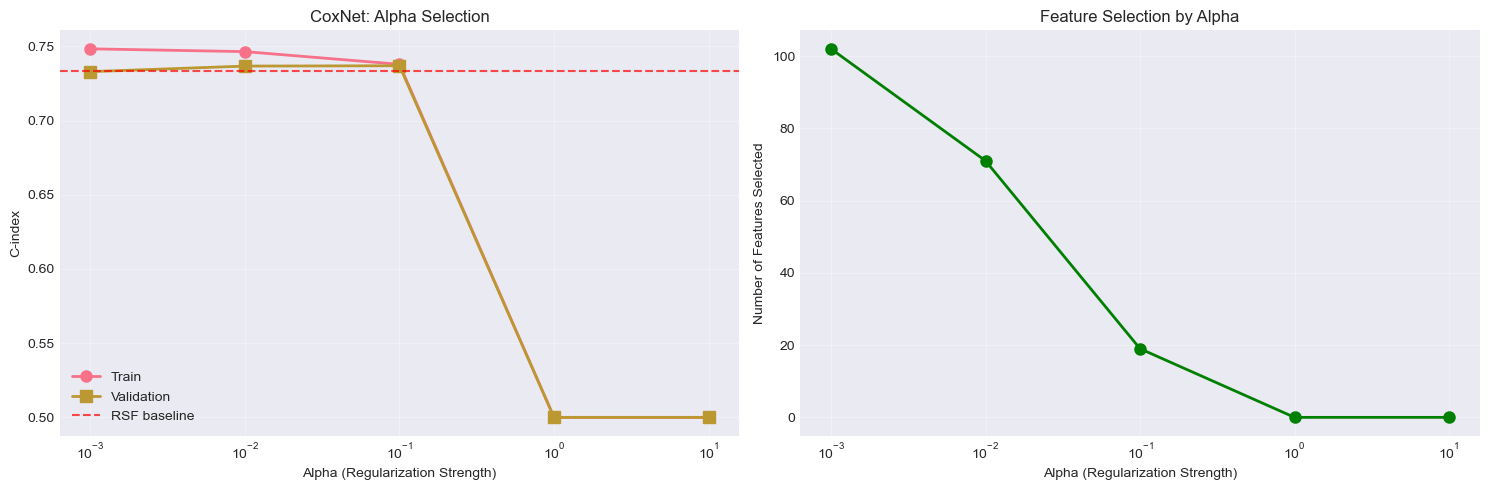

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Cross-validation results
ax1.plot(results_df['alpha'], results_df['c_index_train'], 'o-', label='Train', linewidth=2, markersize=8)
ax1.plot(results_df['alpha'], results_df['c_index_val'], 's-', label='Validation', linewidth=2, markersize=8)
ax1.axhline(y=0.7334, color='r', linestyle='--', label='RSF baseline', alpha=0.7)
ax1.set_xscale('log')
ax1.set_xlabel('Alpha (Regularization Strength)')
ax1.set_ylabel('C-index')
ax1.set_title('CoxNet: Alpha Selection')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Feature selection (number of features vs alpha)
ax2.plot(results_df['alpha'], results_df['n_features_selected'], 'o-', 
         linewidth=2, markersize=8, color='green')
ax2.set_xscale('log')
ax2.set_xlabel('Alpha (Regularization Strength)')
ax2.set_ylabel('Number of Features Selected')
ax2.set_title('Feature Selection by Alpha')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Top Features Visualization

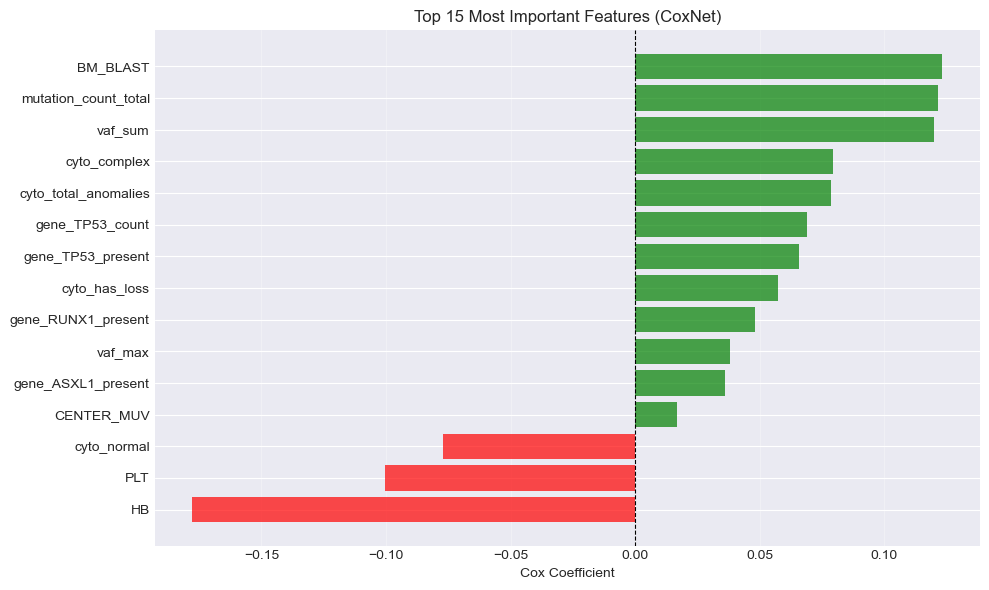

Note: Positive coefficient = higher risk, Negative coefficient = lower risk


In [11]:
# Plot top 15 features
top_15 = feature_importance.head(15).copy()
top_15 = top_15.sort_values('coefficient')

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in top_15['coefficient']]
plt.barh(range(len(top_15)), top_15['coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Cox Coefficient')
plt.title('Top 15 Most Important Features (CoxNet)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Note: Positive coefficient = higher risk, Negative coefficient = lower risk")

## 11. Predictions on Test Set

In [ ]:
# Generate predictions
test_risk_scores = coxnet_final.predict(X_scaled_test.values)

# Create submission
submission = pd.DataFrame({
    'ID': X_scaled_test.index,
    'OS_YEARS': test_risk_scores
})

# Save submission
submission_path = os.path.join(DATA_PATH, "submission_v21_coxnet.csv")
submission.to_csv(submission_path, index=False)

print("="*60)
print("SUBMISSION FILE CREATED")
print("="*60)
print(f"✓ Submission saved: {submission_path}")
print(f"\nSubmission preview:")
print(submission.head(10))
print(f"\nRisk score statistics:")
print(submission['OS_YEARS'].describe())

## 12. Summary

In [ ]:
print("="*60)
print("SUMMARY - CoxNet V21")
print("="*60)
print(f"\nModel Configuration:")
print(f"  - Type: Cox Elastic Net (L1 + L2)")
print(f"  - Best alpha: {best_alpha}")
print(f"  - L1 ratio: 0.5 (50% L1 + 50% L2)")
print(f"  - Features selected: {np.sum(coxnet_final.coef_ != 0)}/{len(coxnet_final.coef_)}")
print(f"\nPerformance:")
print(f"  - Validation C-index: {c_index_val_final:.4f}")
print(f"\nComparison:")
print(f"  - RSF V2:           0.7334")
print(f"  - CoxNet V21:       {c_index_val_final:.4f}")
print(f"\nAdvantages:")
print(f"  ⚡ Very fast training (seconds vs minutes)")
print(f"  🎯 Automatic feature selection (L1 penalty)")
print(f"  📊 Interpretable (direct coefficient interpretation)")
print(f"  🔧 Good regularization (less overfitting)")
print(f"\nNext Steps:")
print(f"  - Ready for ensemble with RSF + Neural Network")
print(f"  - Can try different l1_ratio values (0.1, 0.9)")
print(f"  - Submit if performance is satisfactory")
print("="*60)